# Setup

In [1]:
import numpy as np, timeit, time, matplotlib.pyplot as plt, json, os
from tqdm import tqdm

In [2]:
from binary_models import *
from benchmark_models import get_SMK_SCM
from benchmark_models import nSMK_model, get_avg_nSMK_SCM, get_lucb_nSMK_SCM
from evaluation import evaluate_full
# from actualcauses import beam_search, show_rules, iterative_identification
# from actualcauses.base_algorithm import *
from actualcauses_local.base_algorithm import beam_search, get_rules, get_initial_rules
from actualcauses_local.lucb import *
from actualcauses_local.iterative_subinstance_algorithm import iterative_identification as isi
from general import *

In [3]:
from experiments import run_noisy_SMK

In [4]:
np.set_printoptions(suppress=True)

# Functions

In [5]:
def var2label(S, variables):
    return {variables[i] for i in S}

In [6]:
def make_one_lucb(rules, seed=1):
    np.random.seed(seed)
    out = lucb(simulation, rules, **lucb_params)
    lucb_scores = [elt[1] for elt in out]
    
    avg_out = np.array([[[simulation(rule)[1],simulation(rule)[2]] for _ in range(N)] for rule in rules])
    avg_scores = avg_out[:,:,0].mean(1)
    
    compute_comparison(rules, avg_scores, lucb_scores, full_verbose=False)
    
    sorted_ids = sorted(range(len(rules)), key=lambda i: [out[i][1], out[i][2]])
    beam = [rules[i] for i in sorted_ids[:bs]]
    next_rules = get_rules(beam, SCM_lucb["domains"], SCM_lucb["instance"], [])

    found_vars = {variables[i] for i in sorted_ids[:bs]}
    exp_vars = {variables[i] for i in set().union(*ref_causes)}
    # print("Found:", found_vars)
    # print("Exp:", exp_vars)
    # print("Correct:", found_vars & exp_vars)
    # print("Missed:", exp_vars - found_vars)
    # print("Added:", found_vars - exp_vars)
    found_naive = {variables[i] for i in np.argsort(avg_scores)[:bs]}
    print(f"Prop correct: lucb={len(found_vars & exp_vars)/bs:.2f} / naive={len(found_naive & exp_vars)/bs:.2f}")
    
    return out, lucb_scores, avg_scores, next_rules

In [7]:
def get_avg_out(rules, simulation, seed=None):
    if seed is not None: np.random.seed(seed)
    out = []
    for rule in rules:
        line = []
        for _ in range(N):
            sim_out = simulation(rule)
            line.append((sim_out[1],sim_out[2]))
        out.append(line)
    return np.array(out)

In [8]:
def compare_prop_corect(rules, nl, n_seeds=30):
    prop_lucb = []
    prop_naive = []
    simulation = lambda rule: nSMK_simulation(rule, u, n, nl)
    exp_vars = {variables[i] for i in set().union(*[elt[3] for elt in sbs_causes])}
    
    for seed in tqdm(range(n_seeds)):
        np.random.seed(seed)
        
        out = lucb(simulation, rules, **lucb_params|{"verbose":0})
        sorted_ids = sorted(range(len(rules)), key=lambda i: [out[i][1], out[i][2]])
        found_vars = {variables[i] for i in sorted_ids[:bs]}
        prop_lucb.append(len(found_vars & exp_vars)/bs)
        
        avg_out = get_avg_out(rules, simulation)
        avg_scores = avg_out[:,:,0].mean(1)
        found_naive = {variables[i] for i in np.argsort(avg_scores)[:bs]}
        prop_naive.append(len(found_naive & exp_vars)/bs)

    print(f"Prop lucb: {np.mean(prop_lucb):.2f}±{np.std(prop_lucb):.2f}")  
    print(f"Prop naive: {np.mean(prop_naive):.2f}±{np.std(prop_naive):.2f}")           

In [9]:
def get_data_n_attacker(n):
    with open("../results/base-exact/structured.json") as file:
        data = json.load(file)
    for data_attacker in data:
        if data_attacker["n_attacker"] == n:
            return data_attacker["results"]
    raise f"{n=} not found"

In [10]:
def get_ref(n=5, instance_id=0):
    data = json.load(open("../results/base-exact/structured.json"))
    for dat_attacker in data:
        if dat_attacker["n_attacker"] == n:
            break
    else:
        raise f"{n=} not found"
    exact_res = dat_attacker["results"]
    
    u = exact_res[instance_id]["context"]
    exact_causes = exact_res[instance_id]["causes"]
    exact_e = exact_res[instance_id]["rules"]
    return u, exact_causes, exact_e

In [11]:
def test_context_multi_seeds(n, n_seeds):
    exact_res = get_data_n_attacker(n)

    evals = []
    for instance_id, instance in enumerate(exact_res):
        u = instance["context"]
        exact_causes = instance["causes"]
        ref_causes = list(map(tuple,exact_causes))
        
        scm = get_SMK_SCM(n, u)
        output_det = beam_search(**scm.get_input(), max_steps=4, beam_size=bs,verbose=0)
        det_causes = [tuple(elt[3]) for elt in output_det]
        det_eval = evaluate_full(det_causes, ref_causes)
        # print(ref_causes, det_causes)
        if det_eval["F1"] < .05: continue 
        print(instance_id, end = " ")
        print(f"Deterministic: {det_eval["F1"]:.2f}", end=" / ")

        eval_list = []
        for seed in tqdm(range(n_seeds)):
            SCM_avg = get_avg_nSMK_SCM(n, u, lucb_params["max_iter"], nl)
            output_avg = beam_search(**SCM_avg.get_input(), max_steps=4, beam_size=bs,verbose=0, epsilon=eps)
            avg_causes = [tuple(elt[3]) for elt in output_avg]
            avg_eval = evaluate_full(avg_causes, ref_causes)
    
            SCM_lucb = get_lucb_nSMK_SCM(n, u, nl, lucb_params|{"verbose":0})
            output_lucb = beam_search(**SCM_lucb.get_input(), max_steps=4, beam_size=bs, verbose=0, epsilon=eps)
            lucb_causes = [tuple(elt[3]) for elt in output_lucb]
            lucb_eval = evaluate_full(lucb_causes, ref_causes)
            eval_list.append((avg_eval["F1"], lucb_eval["F1"]))
        eval_list = np.array(eval_list)
        print(f"Naive: {eval_list[:,0].mean():.2f}±{eval_list[:,0].std():.2f} / LUCB: {eval_list[:,1].mean():.2f}±{eval_list[:,1].std():.2f}")
        evals.append(eval_list.mean(0))
    evals = np.array(evals)
    print(f"Naive: {evals[:,0].mean():.2f}±{evals[:,0].std():.2f} / LUCB: {evals[:,1].mean():.2f}±{evals[:,1].std():.2f}")

In [12]:
def interpolate(x, vmin=None, vmax=None, vrefs=None):
    # return x
    if vrefs is not None:
        vmin = np.min(vrefs)
        vmax = np.max(vrefs)
    else:
        if vmin is None:
            vmin = np.min(x)
        if vmax is None:
            vmax = np.max(x)
    
    if vmin == vmax: return x
    return (x - vmin) / (vmax - vmin)

# Main

Problem to solve: for 5/10 attackers, LUCB misses way more than naive sampling

In [40]:
n = 5
variables = get_SMK_V(n)

bs = 50
max_iter = 100
eps = .65
nl = 2.5
lucb_params = {"beam_size": bs, "a": eps, 
               "cause_eps": .05, 
               "beam_eps": .1, 
               "non_cause_eps": .05, 
               "max_iter": max_iter, 
               "verbose": 2, 
               "init_batch_size": 20,
               "batch_size": 5
               }
lucb_params["init_batch_size"], lucb_params["batch_size"]

(20, 5)

## Granular tests

In [41]:
u, exact_causes, exact_e = get_ref(n, 0)
ref_causes = list(map(tuple,exact_causes))
var_cause = np.array(list({var for cause in ref_causes for var in cause}))

In [42]:
# Compute

# Build rules and refs
scm = get_SMK_SCM(n, u)
rules_1 = get_initial_rules(scm.V[:-1],scm.D[:-1], scm.v[:-1])
rules_2 = get_rules(rules_1, scm.V[:-1],scm.D[:-1],scm.v[:-1], [], dict(zip(scm.V, scm.v)))
rules = rules_2
x = np.arange(len(rules))
ref_out = scm.apply_interventions(rules)
ref_psi = np.array([elt[2]/len(scm.V) for elt in ref_out])
ref_phi = np.array([elt[1] for elt in ref_out])
sorted_ids_phi = np.argsort(ref_phi)
sorted_ids_psi = np.argsort(ref_psi)

# Compute average
scm_avg = get_avg_nSMK_SCM(n, u, max_iter, nl)
out_avg = scm_avg.apply_interventions(rules)
avg_psi = np.array([elt[2]/len(scm_avg.V) for elt in out_avg])
avg_phi = np.array([elt[1] for elt in out_avg])

# Compute lucb
scm_lucb = get_lucb_nSMK_SCM(n, u, nl,lucb_params|{"verbose":2})
out_lucb = scm_lucb.apply_interventions(rules)
lucb_psi = np.array([elt[2] for elt in out_lucb])
lucb_phi = np.array([elt[1] for elt in out_lucb])
lucb_iter = np.array([elt[0][-1] for elt in out_lucb])

100%|██████████| 4788/4788 [00:03<00:00, 1386.65it/s]
 73%|███████▎  | 350340.0/478800 [00:34<00:12, 10030.52it/s]

Success: beam_bound=0.0870 / cause_bound=-0.0727 / non_cause_bound=-0.0227)


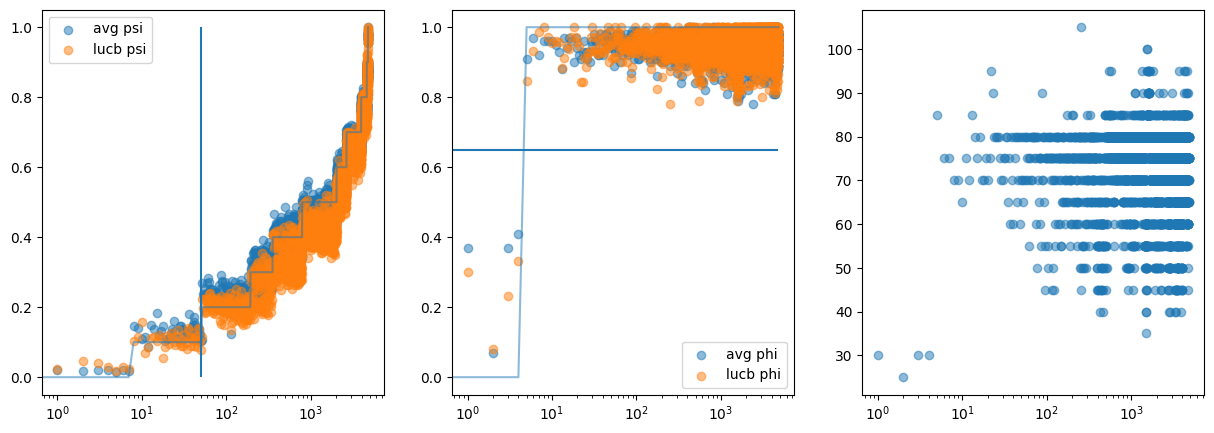

In [43]:
_, axes = plt.subplots(1,3,figsize=(15,5))
max_x = -1

# sorted_ids_psi = np.argsort(avg_large_psi)
# sorted_ids_phi = np.argsort(avg_large_psi)
plot_ids_psi = [i for i in sorted_ids_psi if ref_phi[i] == 1][:max_x]

def filter_psi(values):
    values = interpolate(values[plot_ids_psi])
    return np.arange(len(values)), values

alpha = .5
# Plot refs
axes[0].plot(*filter_psi(ref_psi), alpha=alpha)#, c=c)
axes[1].plot(ref_phi[sorted_ids_phi][:max_x], alpha=alpha)#, c=c)

axes[0].vlines(bs, 0, 1)
axes[1].hlines(eps, 0, len(rules[:max_x]))

# Average
# avg_colors = np.array(["orange" if value < sorted(avg_psi[plot_ids_psi])[bs] else "purple" for value in avg_psi])
axes[0].scatter(*filter_psi(avg_psi), alpha=alpha, label="avg psi")#, c=avg_colors[plot_ids_psi])
axes[1].scatter(x[:max_x], avg_phi[sorted_ids_phi][:max_x], alpha=alpha, label="avg phi")

# axes[0].plot(interpolate(avg_large_psi[sorted_ids_psi])[:max_x], label="large")
# axes[1].plot(avg_large_psi[sorted_ids_phi][:max_x], label="large")

# LUCB
# lucb_colors = np.array(["black" if value < sorted(lucb_psi[plot_ids_psi])[bs] else "red" for value in lucb_psi])
axes[0].scatter(*filter_psi(lucb_psi), alpha=alpha, label="lucb psi")#, c=lucb_colors[plot_ids_psi])
axes[1].scatter(x[:max_x], lucb_phi[sorted_ids_phi][:max_x], alpha=alpha, label="lucb phi")
axes[2].scatter(x[:max_x], lucb_iter[sorted_ids_phi][:max_x], alpha=alpha)

# axes[0].plot(sorted(lucb_psi))
# lucb_threshold = sorted(lucb_psi)[bs]
# axes[0].hlines(lucb_threshold, 0,len(rules))
# axes[0].scatter(sorted_ids_psi[lucb_threshold],[lucb_psi[lucb_threshold]])

axes[0].set_xscale('log')
axes[0].legend()
axes[1].set_xscale('log')
axes[1].legend()
axes[2].set_xscale('log')

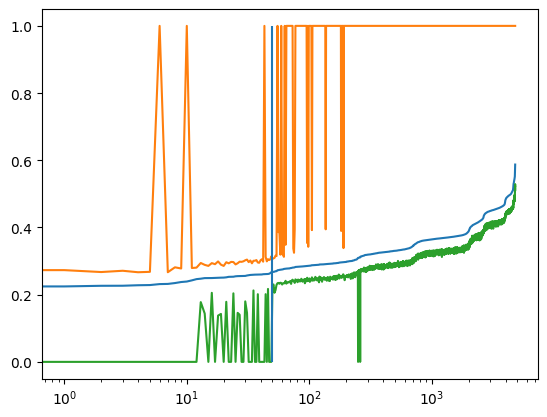

In [44]:
lucb_lb = np.array([elt[0][6] for elt in out_lucb])
lucb_ub = np.array([elt[0][7] for elt in out_lucb])
sorted_lucb_ids = np.argsort(lucb_psi)
plt.plot(lucb_psi[sorted_lucb_ids])
plt.plot(lucb_lb[sorted_lucb_ids])
plt.plot(lucb_ub[sorted_lucb_ids])
plt.vlines(bs, 0, 1)
plt.xscale('log')

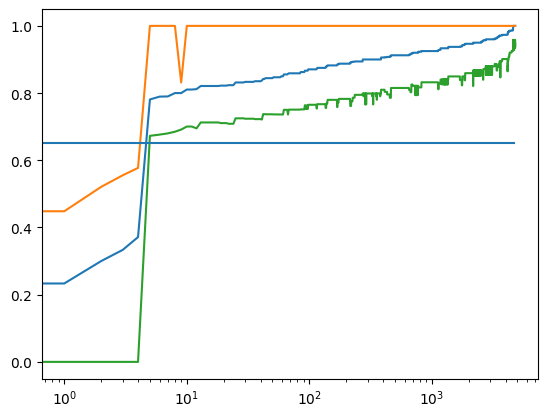

In [45]:
lucb_lb = np.array([elt[0][1] for elt in out_lucb])
lucb_ub = np.array([elt[0][2] for elt in out_lucb])
sorted_lucb_ids = np.argsort(lucb_phi)
plt.plot(lucb_phi[sorted_lucb_ids])
plt.plot(lucb_lb[sorted_lucb_ids])
plt.plot(lucb_ub[sorted_lucb_ids])
plt.hlines(eps, 0, len(rules))
plt.xscale('log')

## General tests

In [19]:
# test_context_multi_seeds(n, n_seeds)

## Single overall test

In [20]:
# u, exact_causes, exact_e = get_ref(n=n, instance_id=12)

In [21]:
# print(f"Found {len(exact_causes)} causes")
# print(f"Size of the interventions: {[list(map(len,exact_e))]}")

In [22]:
# ref_causes = list(map(tuple,exact_causes))

In [23]:
# list(map(lambda C: var2label(C, variables), ref_causes))

In [24]:
# SCM_avg = get_avg_nSMK_SCM(n, u, N, nl)
# SCM_lucb = get_lucb_nSMK_SCM(n, u, nl, lucb_params)
# scm = get_SMK_SCM(n, u)

In [25]:
# np.random.seed(42)
# output_avg = beam_search(**SCM_avg.get_input(), max_steps=4, beam_size=bs,verbose=2, epsilon=eps)
# print("\nRESULTS\n")
# show_rules(output_avg, SCM_avg.V)

In [26]:
# np.random.seed(42)
# output_lucb = beam_search(**SCM_lucb.get_input(), max_steps=4, beam_size=bs,verbose=2, epsilon=eps)
# print("\nRESULTS\n")
# show_rules(output_lucb, SCM_lucb.V)

In [27]:
# avg_causes = [tuple(elt[3]) for elt in output_avg]
# lucb_causes = [tuple(elt[3]) for elt in output_lucb]
# avg_F1 = evaluate_full(avg_causes, ref_causes)["F1"]
# lucb_F1 = evaluate_full(lucb_causes, ref_causes)["F1"]
# print(f"Naive: {avg_F1:.2f} / LUCB: {lucb_F1:.2f}")